# Neural Network from Scratch

![](images/image1.png)

Chia-Hung Yuan & DataLab Fall 2020
In this tutorial, you will learn the fundamentals of how you can build neural networks without the help of the deep learning frameworks, and instead by using NumPy.

Creating complex neural networks with difference architectures in Python should be a standard practice for any ML Engineer and Data Scientist. But a genuine understanding of how a neural network works is equally as valuable.This is what we aim to expand on in this article, the very fundamentals on how we can build neural networks, without the help of the frameworks that make it easy for us.

# Model Architecture

We are building a basic deep neural network with 3 layers in total:
- 1 input layer
- 1 hidden layers
- 1 output layer

All layers will be fully connected. We implement ReLU and sigmoid activation functions, SGD and Momentum optimizer are available.

Let's try to define the layers in an exact way. To be able to classify digits, we must end up withthe proabilities of an image belonging to a certain class, after running the neural network, because then we can quantify how well our neural network performed.

1. Input layer: In this layer, we input and our dataset, consisting of $28\times28=784$ elements. This means our input layer will have 784 nodes.

2. Hidden layer: In this layer, we have decided to reduct the number of nodes from 784 in the input layer to 64 nodes.

3. Output layer: In this layer, we are reducing the 64 nodes to a total of 10 nodes, so that we can evaluate the node againts the label. This label is received in the form of an array with 10 elements, where one of the elementsis 1, while the rest is 0.

In [23]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import time

import numpy as np
import struct
from array import array
from os.path import join

%matplotlib inline
import random
import matplotlib.pyplot as plt

# Helper Function

In [24]:
# Helper functions
def show_images(
    image,
    num_row=2,
    num_col=5
):
    image_size = int(np.sqrt(image.shape[-1]))
    image = np.reshape(image, (image.shape[0], image_size, image_size))
    fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))

    for i in range(num_row*num_col):
        ax = axes[i//num_col, i%num_col]
        ax.imshow(image[i], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def one_hot(x, k, dtype=np.float32):
    """Create a one-hot encoding of x of size k."""
    return np.array(x[:, None] == np.arange(k), dtype)

# Dataset Preparation

In this turorial, we will use MNIST dataset to demo how build a neural network. MNIST contains 70.000 images of hand-written digits, 60.000 for training while 10.000 for testing. Each $28\times28$ pixel, in greyscale with pixel-valu from 0 to 255.

You might notice we not only import Numpy, but also Scikit-learn and Matplotlib. Matplotlib helps us visualize the training data, while Scikit-learn let us load the dataset more easily, but they are not used for any of the actual neural network. There are many ways to load dataset, you can choose any one you prefer.

### Note

You might notice we not only import Numpy, but also Scikit-learn and Matplotlib. Matplotlib helps us visualize the training data, while Scikit-learn let us load the dataset more easily, but they are not used for any of the actual neural network. There are many ways to load dataset, you can choose any one you prefer.

### Load data

In [25]:
class MnistDataloader(object):

    def __init__(
        self,
        training_images_filepath,
        training_labels_filepath,
        test_images_filepath,
        test_labels_filepath,
        num_classes=10
    ):

        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
        self.num_classes = num_classes

    def read_images_labels(
        self,
        images_filepath,
        labels_filepath
    ):
        with open(labels_filepath, 'rb') as file:
            magic,size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(f'Label magic number mismatch: {magic}')
            labels = np.frombuffer(
                file.read(),
                dtype=np.uint8
            )

        
        with open(images_filepath, 'rb') as file:
            magic, size_img, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(f'Image magic number mismatch: {magic}')
            image_data = np.frombuffer(
                file.read(),
                dtype=np.uint8
            )

        assert size == size_img


        # RESHAPE + NORMALIZE
        images = image_data.reshape(
            size,
            rows * cols
        ).astype(np.float32)

        images /= 255.0


        # ONEHOT LABELS
        labels = one_hot(labels, self.num_classes)

        return images, labels
        

    
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)   

Training data: (60000, 784) (60000, 10)
Test data: (10000, 784) (10000, 10)


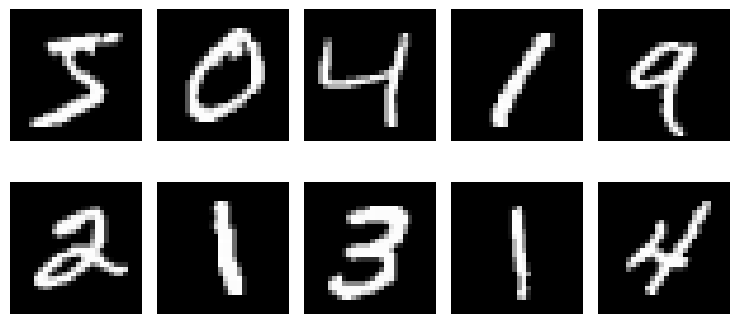

In [26]:
#
# Set file paths based on added MNIST Datasets
#
input_path = './datasets'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(
    training_images_filepath, 
    training_labels_filepath, 
    test_images_filepath, 
    test_labels_filepath,
    num_classes=10
)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()


print("Training data: {} {}".format(x_train.shape, y_train.shape))
print("Test data: {} {}".format(x_test.shape, y_test.shape))
show_images(
    x_train, 
    num_row=2,
    num_col=5
)


# Initialization

The specific problem that arises, when trying to implement the feedforward network, is that we are trying to transform from 784 nodes all the way down to 10 nodes. When instantiating the DeepNeuralNetwork class, we pass in an array of sizes that defines the number of activations for each layer.

$dnn = DeepNeuralNetwork(sizes=[784, 64, 10])$

This initializes the DeepNeuralNetwork class by the init function.

In [27]:
def __init__(
    self,
    sizes, 
    activation="sigmoid"
):
    self.sizes = sizes

    # Choose activation function
    if activation == 'relu':
        self.activation = self.relu
    elif activation == 'sigmoid':
        self.activation = self.sigmoid

    # Save all weights
    self.params = self.initialize()
    # Save all intermediate values, i.e. activations
    self.cache = {}
    

To smarten up our initialization, we shrink the variance of the weights in each layer. We'll set the variance for each layer to $\frac{1}{n}$, where n is the number of inputs feeding standard normal distribution. So to adjust the variance to $\frac{1}{n}$, we just divided by $\sqrt{n}$.

The initialization of weights in the neural network is kind of hard to think about. To really understand how and why the following approach works, you need a grasp of linear algebra, specifically dimensionality when using the dot product operation, which is beyond the scope of this class.

In [28]:
def initialization(self):

    # number of nodes in each layer
    input_layer = self.sizes[0]
    hidden_1 = self.sizes[1]
    hidden_2 = self.sizes[2]
    output_layer = self.sizes[3]

    params = {
        'W1': np.random.randn(
            hidden_1,
            input_layer
        ) * np.sqrt(1./hidden_1),
        'W2': np.random.rand(
            hidden_2,
            hidden_1
        ) * np.sqrt(1./hidden_2),
        'W3': np.random.rand(
            output_layer,
            hidden_2
        ) * np.sqrt(1./output_layer)
    }

    return params

# Feedforward

The forward pass consists of the dot operation in NumPy, which turns out to be just matrix multiplication. As described in the introduction to neural networks article, we have to multiply the weights by the activations of the previous layer. Then we have to apply the activation function to the outcome.

To get through each layer, we sequentially apply the dot operation, followed by the sigmoid/relu activation function. In the last layer we use the softmax activation function, since we wish to have probabilities of each class, so that we can measure how well our current forward pass performs.

Forward pass:
$$
A^{(0)} \leftarrow [a^{(0,1)} ... a^{(0.M)}]^{T}
$$

$for \space k \leftarrow 1  \space to \space L \space do$

$Z^{(k)} \leftarrow A^{(k-1).W^{(k)}}$

$A^{(k)} \leftarrow act(Z^{(k)})$

In [29]:
def feed_forward(
        self,
        x
):
    self.cache["X"] = x

    self.cache["Z1"] = np.matmul(
        self.params["W1"],
        self.cache["X"].T) + self.params["b1"]

    self.cache["A1"] = self.activation(self.cache["Z1"])

    self.cache["Z2"] = np.matmul(
        self.params["W2"],
        self.cache["A1"]
    ) + self.params["b2"]

    self.cache["A2"] = self.activation(self.cache["Z2"])

    return self.cache["A2"]

The following are the activation functions used for this article. As you can see, we provide a derivative sersion of the relu and sigmoid, since we will need that later on when backpropagating through the neural network.

#### ReLU

Mathematics:
$$
ReLU(x) = max(0,x)
$$

Derivative:
$$
ReLU^{'}(x) =
\begin{cases}
0 & \text{if} \space x < 0 \\
1 & \text{if} \space x > 0
\end{cases}
$$

In [30]:
def relu(
        self,
        x,
        derivative=False
):
    if derivative:
        x = np.where(x < 0, 0, x)
        x = np.where(x > 0, 1, x)

        return x

    return  np.maximum(0, x)

#### Sigmoid

Mathematics:
$$
Sigmoid(x) = \frac{e^{-x}}{(e^{-x}+1)^2}
$$

Derivative:
$$
Sigmoid^{'}(x) = \frac{1}{1 + e^{-x}}
$$

In [31]:
def sigmoid(
        self,
        x,
        derivative=False
):
    if derivative:
        x = (np.exp(-x) / (np.exp(-x) + 1)**2)
        return x

    return 1 / (1 + np.exp(-x))

#### Softmax

In [32]:
def softmax(
        self,
        x
):
    # Numerically stable with large exponenetial
    exps = np.exp(x - x.max())
    return exps / np.sum(exps, axis=0)

# Backpropagation

The backward pass is hard to get right, because there are so many sizes and operations that have to align, for all the operations to be successful. Here is the full function for the backward pass; we will go through each weight update below

Backward pass:

Compute error signals
$\triangle^{(L)} = [\delta^{(L,0)} ... \delta^{(L,M)}]^{T}$

$
for \space k \leftarrow L - 1 \space to \space 1 \space do
$

$
\space \triangle^{(k)} = act^{'}(Z^{(k)}) ⊙ (\triangle^{(k+1)}.W^{(k+1)^{T}})
$

Return $\frac{\partial c^{(n)}}{\partial W^{(k)}} = \sum^{M}_{n=1}{a^{(k-1,n)}}.\delta^{(k,n)}$ for all $k$

In [33]:
def back_propagate(
        self,
        y,
        output
):

    current_batch_size = y.shape[0]

    dZ2 = output - y.T

    dW2 = (1./current_batch_size) * np.matmul(
        dZ2,
        self.cache["A1"].T
    )

    db2 = (1./current_batch_size) * np.sum(
        dZ2,
        axis=1,
        keepdims=True
    )

    dA1 = np.matmul(
        self.params["W2"].T,
        dZ2
    )

    dZ1 = dA1 * self.activation(
        self.cache["Z1"],
        derivative=True
    )


    dW1 = (1./current_batch_size) * np.matmul(
        dZ1,
        self.cache["A1"]
    )

    db1 = (1./current_batch_size) * np.sum(
        dZ1,
        axis=1,
        keepdims=True
    )

    self.grads = {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
    }

    return self.grads

# Training (Stochasic Gradient Descent)

We have defined a forward and backward pass, but how can we start using them? We have to make a training loop and choose to use Stochastic Gradient Descent (SGD) as the optimizer to update the parameters of the neural network.

There are two main loops in the training function. One loop for the number of epochs, which is the number of times we run through the whole dataset, and a second loop for running through each batch one by one.

For each batch, we do a forward pass by calling self.feedforward() with x, which is one batch in an array with the length 784, as explained earlier. The output of the forward pass is used along with y, which are the one-hot encoded labels (the ground truth), in the backward pass. self.back_propagate() returns the gradients of weights

In [34]:
def train(
        self,
        x_train,
        y_train,
        x_test,
        y_test
):

    for i in range(self.epochs):
        # Shuffle
        permutation = np.random.permutation(x_train.shape[0])
        x_train_shuffled = x_train[permutation]
        y_train_shuffled = y_train[permutation]

        for j in range(num_batches):
            # Batch
            begin = j * self.batch_size
            end = min(begin + self.batch_size, x_train.shape[0] - 1)

            x = x_train_shuffled[begin:end]
            y = y_train_shuffled[begin:end]

            # Forward
            output = self.feed_forward(x)

            # Backpropagate
            grad = self.back_propagate(y, output)

            # Optimize
            self.optimize(l_rate=l_rate, beta=beta)

The optimize() function has the code for both SGD and momentum update rules. SGD algorithm is relatively straightforward, updating the networks by calculated gradient directly, while momentum make the same movement in the last iteration, corrected by negative gradient.

#### SGD

Mathematics:
$$
\theta_{t+1} = \theta_{t} - \eta.g_{t}
$$
- $g_{t}$: gradient at $t$

#### Momentum

Mathematics:
$$
v_{1} = \beta.v_{t-1} + (1-\beta).g_{t}
$$

- $g_{t}$: gradient at $t$

$$
\theta_{t+1} = \theta_{t}-\eta.v_{t}
$$

![](images/image2.png)

In [35]:
def optimize(
        self,
        l_rate=0.1,
        beta=.9
):
    if self.optimizer == "sgd":
        for key in self.params:
            self.params[key] = self.params[key] - l_rate*self.grads[key]

    elif self.optimizer == "momentum":
        for key in self.params:
            self.momemtum_otp[key] = (beta*self.momemtum_otp[key] + (1.-beta)*self.grads[key])
            self.params[key] = self.params[key] - l_rate*self.momemtum_opt[key]

After having updated the parameters of the neural network, we can measure the accuracy on a validation set that we conveniently prepared earlier, to validate how well our network performs after each iteration over the whole dataset.

In [36]:
def accuracy(
        self,
        y,
        output
):
    return np.mean(
        np.argmax(y, axis=-1) == np.argmax(output.T, axis=-1)
    )

Finally, we can call the training function, after knowing what will happen. We use the training and validation data as input to the training function, and then we wait.

# 3-layer neural network with Numpy

Here is the full code, for an easy copy-paste and overview of what's happening.

In [37]:
class DeepNeuralNetwork:

    def __init__(self, sizes, activation='sigmoid'):
        self.sizes = sizes

        # Choose activation function
        if activation == 'relu':
            self.activation = self.relu
        elif activation == 'sigmoid':
            self.activation = self.sigmoid
        else:
            raise ValueError("Activation function is currently not support, please use 'relu' or 'sigmoid' instead.")

        # Save all weights
        self.params = self.initialize()
        # Save all intermediate values, i.e. activations
        self.cache = {}


    def relu(self, x, derivative=False):
        if derivative:
            x = np.where(x < 0, 0, x)
            x = np.where(x >= 0, 1, x)
            return x
        return np.maximum(0, x)


    def sigmoid(self, x, derivative=False):
        if derivative:
            return (np.exp(-x))/((np.exp(-x)+1)**2)
        return 1/(1 + np.exp(-x))


    def softmax(self, x):
        # Numerically stable with large exponentials
        exps = np.exp(x - x.max())
        return exps / np.sum(exps, axis=0)


    def initialize(self):
        # number of nodes in each layer
        input_layer=self.sizes[0]
        hidden_layer=self.sizes[1]
        output_layer=self.sizes[2]

        params = {
            "W1": np.random.randn(hidden_layer, input_layer) * np.sqrt(1./input_layer),
            "b1": np.zeros((hidden_layer, 1)) * np.sqrt(1./input_layer),
            "W2": np.random.randn(output_layer, hidden_layer) * np.sqrt(1./hidden_layer),
            "b2": np.zeros((output_layer, 1)) * np.sqrt(1./hidden_layer)
        }
        return params


    def initialize_momemtum_optimizer(self):
        momemtum_opt = {
            "W1": np.zeros(self.params["W1"].shape),
            "b1": np.zeros(self.params["b1"].shape),
            "W2": np.zeros(self.params["W2"].shape),
            "b2": np.zeros(self.params["b2"].shape),
        }
        return momemtum_opt


    def feed_forward(self, x):
        self.cache["X"] = x
        self.cache["Z1"] = np.matmul(self.params["W1"], self.cache["X"].T) + self.params["b1"]
        self.cache["A1"] = self.activation(self.cache["Z1"])
        self.cache["Z2"] = np.matmul(self.params["W2"], self.cache["A1"]) + self.params["b2"]
        self.cache["A2"] = self.softmax(self.cache["Z2"])
        return self.cache["A2"]



    def back_propagate(self, y, output):

        current_batch_size = y.shape[0]

        dZ2 = output - y.T
        dW2 = (1./current_batch_size) * np.matmul(dZ2, self.cache["A1"].T)
        db2 = (1./current_batch_size) * np.sum(dZ2, axis=1, keepdims=True)

        dA1 = np.matmul(self.params["W2"].T, dZ2)
        dZ1 = dA1 * self.activation(self.cache["Z1"], derivative=True)
        dW1 = (1./current_batch_size) * np.matmul(dZ1, self.cache["X"])
        db1 = (1./current_batch_size) * np.sum(dZ1, axis=1, keepdims=True)

        self.grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}
        return self.grads


    def cross_entropy_loss(self, y, output):
        '''
            L(y, ŷ) = −∑ylog(ŷ).
        '''
        l_sum = np.sum(np.multiply(y.T, np.log(output)))
        m = y.shape[0]
        l = -(1./m) * l_sum
        return l


    def optimize(self, l_rate=0.1, beta=.9):
        '''
            Stochatic Gradient Descent (SGD):
            θ^(t+1) <- θ^t - η∇L(y, ŷ)

            Momentum:
            v^(t+1) <- βv^t + (1-β)∇L(y, ŷ)^t
            θ^(t+1) <- θ^t - ηv^(t+1)
        '''
        if self.optimizer == "sgd":
            for key in self.params:
                self.params[key] = self.params[key] - l_rate * self.grads[key]
        elif self.optimizer == "momentum":
            for key in self.params:
                self.momemtum_opt[key] = (beta * self.momemtum_opt[key] + (1. - beta) * self.grads[key])
                self.params[key] = self.params[key] - l_rate * self.momemtum_opt[key]
        else:
            raise ValueError("Optimizer is currently not support, please use 'sgd' or 'momentum' instead.")

    def accuracy(self, y, output):
        return np.mean(np.argmax(y, axis=-1) == np.argmax(output.T, axis=-1))



    def train(self, x_train, y_train, x_test, y_test, epochs=10,
              batch_size=64, optimizer='momentum', l_rate=0.1, beta=.9):
        # Hyperparameters
        self.epochs = epochs
        self.batch_size = batch_size
        num_batches = -(-x_train.shape[0] // self.batch_size)

        # Initialize optimizer
        self.optimizer = optimizer
        if self.optimizer == 'momentum':
            self.momemtum_opt = self.initialize_momemtum_optimizer()

        start_time = time.time()
        template = "Epoch {}: {:.2f}s, train acc={:.2f}, train loss={:.2f}, test acc={:.2f}, test loss={:.2f}"

        # Train
        for i in range(self.epochs):
            # Shuffle
            permutation = np.random.permutation(x_train.shape[0])
            x_train_shuffled = x_train[permutation]
            y_train_shuffled = y_train[permutation]

            for j in range(num_batches):
                # Batch
                begin = j * self.batch_size
                end = min(begin + self.batch_size, x_train.shape[0]-1)
                x = x_train_shuffled[begin:end]
                y = y_train_shuffled[begin:end]

                # Forward
                output = self.feed_forward(x)
                # Backprop
                grad = self.back_propagate(y, output)
                # Optimize
                self.optimize(l_rate=l_rate, beta=beta)

            # Evaluate performance
            # Training data
            output = self.feed_forward(x_train)
            train_acc = self.accuracy(y_train, output)
            train_loss = self.cross_entropy_loss(y_train, output)
            # Test data
            output = self.feed_forward(x_test)
            test_acc = self.accuracy(y_test, output)
            test_loss = self.cross_entropy_loss(y_test, output)
            print(template.format(i+1, time.time()-start_time, train_acc, train_loss, test_acc, test_loss))


# Result

The results completely dependent on how the weights are initialized and the activation function we use. Experimentally, due to non-bounded behavior of relu(), the learning rate should be set much smaller than the one for sigmoid() (bounded). In addition, training with SGD optimizer with momentum should have better result since it avoids from getting stuck in local minima or saddle points.

The reason behind this phenomenon is complicated and beyond the scope of this class. In short, the training results will be more stable and consistent as the batch size increases.

### Sigmoid + Momentum

In [38]:
dnn = DeepNeuralNetwork(
    sizes=[784, 64, 10],
    activation="sigmoid"
)

In [39]:
dnn.train(
    x_train,
    y_train,
    x_test,
    y_test,
    batch_size=128,
    optimizer="momentum",
    l_rate=4,
    beta=0.9
)

Epoch 1: 0.50s, train acc=0.95, train loss=0.15, test acc=0.95, test loss=0.16
Epoch 2: 0.97s, train acc=0.97, train loss=0.10, test acc=0.96, test loss=0.12
Epoch 3: 1.43s, train acc=0.98, train loss=0.08, test acc=0.97, test loss=0.10
Epoch 4: 1.88s, train acc=0.98, train loss=0.06, test acc=0.97, test loss=0.10
Epoch 5: 2.33s, train acc=0.98, train loss=0.05, test acc=0.97, test loss=0.10
Epoch 6: 2.78s, train acc=0.99, train loss=0.04, test acc=0.97, test loss=0.09
Epoch 7: 3.22s, train acc=0.99, train loss=0.04, test acc=0.97, test loss=0.09
Epoch 8: 3.68s, train acc=0.99, train loss=0.03, test acc=0.97, test loss=0.09
Epoch 9: 4.14s, train acc=0.99, train loss=0.03, test acc=0.97, test loss=0.08
Epoch 10: 4.64s, train acc=0.99, train loss=0.02, test acc=0.98, test loss=0.08


$\rightarrow$ stable, smooth loss

$\rightarrow$ slow

### ReLU + SGD

In [40]:
dnn = DeepNeuralNetwork(
    sizes=[784, 64, 10],
    activation="relu"
)

In [41]:
dnn.train(
    x_train,
    y_train,
    x_test,
    y_test,
    batch_size=128,
    optimizer="sgd",
    l_rate=0.05,
)

Epoch 1: 0.41s, train acc=0.89, train loss=0.40, test acc=0.90, test loss=0.38
Epoch 2: 0.84s, train acc=0.90, train loss=0.33, test acc=0.91, test loss=0.31
Epoch 3: 1.30s, train acc=0.91, train loss=0.30, test acc=0.92, test loss=0.29
Epoch 4: 1.76s, train acc=0.92, train loss=0.29, test acc=0.92, test loss=0.28
Epoch 5: 2.16s, train acc=0.92, train loss=0.28, test acc=0.92, test loss=0.27
Epoch 6: 2.54s, train acc=0.92, train loss=0.27, test acc=0.92, test loss=0.27
Epoch 7: 2.95s, train acc=0.92, train loss=0.27, test acc=0.92, test loss=0.27
Epoch 8: 3.39s, train acc=0.93, train loss=0.26, test acc=0.93, test loss=0.26
Epoch 9: 3.79s, train acc=0.93, train loss=0.25, test acc=0.93, test loss=0.25
Epoch 10: 4.21s, train acc=0.93, train loss=0.25, test acc=0.93, test loss=0.25


$\rightarrow$ learn so fast

$\rightarrow$ more noise/sensitive flex

# Good Exercise in Numpy

You might have noticed that the code is very readable, but takes up a lot of space and could be optimized to run in loops. Here is a chance to optimize and improve the code. For example, you can optimize the forward and backward pass, such that they run in a for loop in each function. This makes the code easier to modify and possibly easier to maintain.

More challenging exercises including implement any other activation function from this overview of activation functions, and remember to implement the derivatives as well. Different optimizers, e.g. Adam, RMSProp, etc, are also worth to try.